<a href="https://colab.research.google.com/github/tamnhm1910/mservice.momotransfer_data_scraping_and_analyzing/blob/main/Momo_Raw_Dataset_ChPlay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00


In [2]:

from google_play_scraper import app, reviews_all, Sort
import pandas as pd # Import pandas for DataFrame
# Momo app ID on Google Play and language
app_id = 'com.mservice.momotransfer'
lang_code = 'vi'
country_code = 'vn'  # Assuming Vietnam for 'vi' language

print(f"Fetching details for Google Play app: {app_id} (Language: {lang_code})\n")

# Fetch app details
result_app = app(
    app_id,
    lang=lang_code,
    country=country_code
)

print("--- App Details ---")
print(f"App Name: {result_app['title']}")
print(f"Developer: {result_app['developer']}")
print(f"Category: {result_app['genre']}")
print(f"Score: {result_app['score']:.2f}")
print(f"Reviews Count: {result_app['reviews']}")
print(f"Installs: {result_app['installs']}")
print(f"Free: {result_app['free']}")
print(f"Price: {result_app['price']}")
print(f"Updated: {result_app['updated']}")
print(f"Version: {result_app['version']}")
print(f"Content Rating: {result_app['contentRating']}")
print(f"URL: {result_app['url']}")

print(f"\n--- Fetching ALL Reviews for {result_app['title']} (Language: {lang_code}) ---")

# Fetch all reviews
reviews_data = reviews_all(
    app_id,
    lang=lang_code,
    country=country_code,
    sort=Sort.NEWEST  # You can change this to Sort.RATING, Sort.HELPFUL, etc.
)

# Convert reviews to a pandas DataFrame for easier viewing and analysis
df_reviews = pd.DataFrame(reviews_data)

print(f"Total reviews fetched: {len(df_reviews)}")

if not df_reviews.empty:
    print("\nFirst 5 reviews:")
    display(df_reviews.head())  # Use display for better DataFrame output
else:
    print("No reviews found or an error occurred.")


Fetching details for Google Play app: com.mservice.momotransfer (Language: vi)

--- App Details ---
App Name: MoMo-Trợ Thủ Tài Chính với AI
Developer: M_SERVICE JSC
Category: Tài chính
Score: 4.22
Reviews Count: 218887
Installs: 10.000.000+
Free: True
Price: 0
Updated: 1774890528
Version: Varies with device
Content Rating: 3 tuổi trở lên
URL: https://play.google.com/store/apps/details?id=com.mservice.momotransfer&hl=vi&gl=vn

--- Fetching ALL Reviews for MoMo-Trợ Thủ Tài Chính với AI (Language: vi) ---
Total reviews fetched: 211905

First 5 reviews:


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,58fa28c1-c91e-4efc-bba8-50a679af90a6,Người dùng Google,https://play-lh.googleusercontent.com/EGemoI2N...,má áp quét mã QR ko đc vô ko đc luôn,1,0,5.7.1,2026-04-21 06:27:44,Cảm ơn bạn đã để lại đánh giá. MoMo rất tiếc k...,2026-04-21 06:30:01,5.7.1
1,5483feda-c296-4e7a-8473-25e60d43283b,Người dùng Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Lỗi liên tục không thấy phản hồi app quá tệ, ă...",1,0,4.2.7,2026-04-21 06:25:03,None,NaT,4.2.7
2,db2a18e2-fd12-47d2-87ba-7bb89d0c27e1,Người dùng Google,https://play-lh.googleusercontent.com/EGemoI2N...,"ứng dụng như cái lol, xác thực sinh trắc học t...",1,0,None,2026-04-21 05:50:36,Cảm ơn bạn đã để lại đánh giá. MoMo rất tiếc k...,2026-04-21 06:00:01,None
3,763e3fa0-6080-42f9-bbaf-f3db73d8ee80,Người dùng Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok đấy,5,0,None,2026-04-21 05:07:18,Cảm ơn bạn đã đánh giá 5 sao cho MoMo!\n\nMoMo...,2026-04-21 05:30:01,None
4,b866909b-c536-49db-8f9c-12877d0d0f2d,Người dùng Google,https://play-lh.googleusercontent.com/EGemoI2N...,bay tiền ko lya do,1,0,None,2026-04-21 03:29:11,Cảm ơn bạn đã để lại đánh giá. MoMo rất tiếc k...,2026-04-21 03:30:01,None


### Data Quality Check: Format, Missing Values, and Basic Spam Detection

First, let's examine the data types and look for missing values.

In [5]:
print("--- DataFrame Info (Data Types) ---")
df_reviews.info()

print("\n--- Missing Values Count ---")
print(df_reviews.isnull().sum())

# Convert 'at' and 'repliedAt' to datetime objects
df_reviews['at'] = pd.to_datetime(df_reviews['at'])
df_reviews['repliedAt'] = pd.to_datetime(df_reviews['repliedAt'])

print("\n--- DataFrame Info After Datetime Conversion ---")
df_reviews.info()

--- DataFrame Info (Data Types) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211905 entries, 0 to 211904
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              211905 non-null  object        
 1   userName              211905 non-null  object        
 2   userImage             211905 non-null  object        
 3   content               211895 non-null  object        
 4   score                 211905 non-null  int64         
 5   thumbsUpCount         211905 non-null  int64         
 6   reviewCreatedVersion  162882 non-null  object        
 7   at                    211905 non-null  datetime64[ns]
 8   replyContent          29563 non-null   object        
 9   repliedAt             29563 non-null   datetime64[ns]
 10  appVersion            162882 non-null  object        
 11  content_length        211905 non-null  int64         
dtypes: datetime64[ns](2), 

Now, let's check for potential 'spam' or low-effort reviews by looking at review length. Very short reviews might be less informative or indicate automated responses.

--- Reviews with very short content (e.g., less than 10 characters) ---


,content,score,userName
3,ok đấy,5,Người dùng Google
9,ok,5,Người dùng Google
18,tốt,5,Người dùng Google
22,thank you,5,Người dùng Google
25,đẳng cấp,5,Người dùng Google


Total very short reviews: 85155


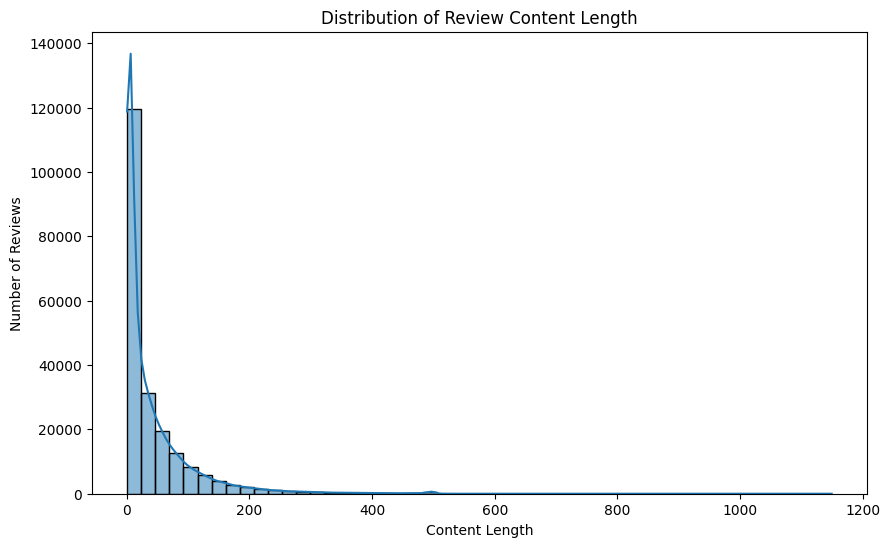

In [4]:
# Calculate review content length
df_reviews['content_length'] = df_reviews['content'].apply(lambda x: len(str(x)))

print("--- Reviews with very short content (e.g., less than 10 characters) ---")
short_reviews = df_reviews[df_reviews['content_length'] < 10]
display(short_reviews[['content', 'score', 'userName']].head())

print(f"Total very short reviews: {len(short_reviews)}")

# Further analysis could involve checking for duplicate content, unusual patterns in scores for short reviews, etc.
# For now, let's look at the distribution of content length.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_reviews['content_length'], bins=50, kde=True)
plt.title('Distribution of Review Content Length')
plt.xlabel('Content Length')
plt.ylabel('Number of Reviews')
plt.show()

### Applying Cleaning Strategy for Missing Values

Based on the decision framework, we'll proceed with the following steps:
1.  Drop rows where `content` is missing or empty.
2.  Create a `has_reply` feature from `replyContent`.
3.  Fill `replyContent` nulls with 'No Reply' while keeping `repliedAt` nulls as `NaT`.

In [6]:
# Create a cleaned DataFrame from the original to apply transformations
df_reviews_clean = df_reviews.copy()

# 1. Drop rows with missing or empty 'content'
initial_rows = len(df_reviews_clean)
df_reviews_clean = df_reviews_clean[
    df_reviews_clean['content'].notna() &
    (df_reviews_clean['content'].astype(str).str.strip() != "")
]
rows_after_content_drop = len(df_reviews_clean)
print(f"Dropped {initial_rows - rows_after_content_drop} rows with missing or empty content.")

# 2. Create 'has_reply' feature from 'replyContent'
df_reviews_clean['has_reply'] = df_reviews_clean['replyContent'].notna()

# 3. Fill 'replyContent' missing values with 'No Reply'
df_reviews_clean['replyContent'] = df_reviews_clean['replyContent'].fillna('No Reply')

# 'repliedAt', 'reviewCreatedVersion', 'appVersion' nulls are retained as per the strategy.

print("\n--- DataFrame Info After Cleaning Steps ---")
df_reviews_clean.info()

print("\n--- Missing Values Count After Cleaning Steps ---")
print(df_reviews_clean.isnull().sum())

print("\n--- First 5 rows of Cleaned DataFrame with new 'has_reply' feature ---")
display(df_reviews_clean.head())

Dropped 10 rows with missing or empty content.

--- DataFrame Info After Cleaning Steps ---
<class 'pandas.core.frame.DataFrame'>
Index: 211895 entries, 0 to 211904
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              211895 non-null  object        
 1   userName              211895 non-null  object        
 2   userImage             211895 non-null  object        
 3   content               211895 non-null  object        
 4   score                 211895 non-null  int64         
 5   thumbsUpCount         211895 non-null  int64         
 6   reviewCreatedVersion  162874 non-null  object        
 7   at                    211895 non-null  datetime64[ns]
 8   replyContent          211895 non-null  object        
 9   repliedAt             29556 non-null   datetime64[ns]
 10  appVersion            162874 non-null  object        
 11  content_length        211895 n

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,content_length,has_reply
0,58fa28c1-c91e-4efc-bba8-50a679af90a6,Người dùng Google,https://play-lh.googleusercontent.com/EGemoI2N...,má áp quét mã QR ko đc vô ko đc luôn,1,0,5.7.1,2026-04-21 06:27:44,Cảm ơn bạn đã để lại đánh giá. MoMo rất tiếc k...,2026-04-21 06:30:01,5.7.1,36,True
1,5483feda-c296-4e7a-8473-25e60d43283b,Người dùng Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Lỗi liên tục không thấy phản hồi app quá tệ, ă...",1,0,4.2.7,2026-04-21 06:25:03,No Reply,NaT,4.2.7,72,False
2,db2a18e2-fd12-47d2-87ba-7bb89d0c27e1,Người dùng Google,https://play-lh.googleusercontent.com/EGemoI2N...,"ứng dụng như cái lol, xác thực sinh trắc học t...",1,0,None,2026-04-21 05:50:36,Cảm ơn bạn đã để lại đánh giá. MoMo rất tiếc k...,2026-04-21 06:00:01,None,138,True
3,763e3fa0-6080-42f9-bbaf-f3db73d8ee80,Người dùng Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok đấy,5,0,None,2026-04-21 05:07:18,Cảm ơn bạn đã đánh giá 5 sao cho MoMo!\n\nMoMo...,2026-04-21 05:30:01,None,6,True
4,b866909b-c536-49db-8f9c-12877d0d0f2d,Người dùng Google,https://play-lh.googleusercontent.com/EGemoI2N...,bay tiền ko lya do,1,0,None,2026-04-21 03:29:11,Cảm ơn bạn đã để lại đánh giá. MoMo rất tiếc k...,2026-04-21 03:30:01,None,18,True


### Save DataFrames to CSV

Saving both the original and cleaned DataFrames to CSV files for further use or download.

In [9]:
# Save the original DataFrame to CSV
df_reviews.to_csv('/tmp/momo_reviews_original.csv', index=False)
print("Original DataFrame saved to '/tmp/momo_reviews_original.csv'")

# Save the cleaned DataFrame to CSV
df_reviews_clean.to_csv('/tmp/momo_reviews_cleaned.csv', index=False)
print("Cleaned DataFrame saved to '/tmp/momo_reviews_cleaned.csv'")

Original DataFrame saved to '/tmp/momo_reviews_original.csv'
Cleaned DataFrame saved to '/tmp/momo_reviews_cleaned.csv'
